## Python for FP&A

This notebook reproduces the practical FP&A workflow: load financial data, inspect/clean it, calculate useful finance metrics, and create management-friendly visualisations.
*italicized text*

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

## 1. Upload your FP&A file

Upload a `.csv`, `.xlsx`, or `.xls` file from your computer.

In [2]:
df = pd.read_excel('/content/FP&A_Trend_Dataset.xlsx')

## 2. Inspect the data

In [4]:
print('01_Column names:')
print(df.columns.tolist())

print('\n02_Data types:')
display(df.dtypes.to_frame('dtype'))

print('\n03_Missing values:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))

print('\n04_Duplicate rows:', df.duplicated().sum())

print('\n05_Numeric summary:')
display(df.describe(include='number').T)


01_Column names:
['Month', 'Revenue ($)', 'COGS ($)', 'Operating_Expenses ($)', 'Net_Profit ($)', 'Active_Customers', 'New_Customers', 'Churn_Rate (%)', 'ARR ($)', 'CAC ($)', 'Employee_Count']

02_Data types:


,dtype
Month,object
Revenue ($),float64
COGS ($),float64
Operating_Expenses ($),float64
Net_Profit ($),float64
Active_Customers,int64
New_Customers,int64
Churn_Rate (%),float64
ARR ($),float64
CAC ($),float64



03_Missing values:


,missing
Month,0
Revenue ($),0
COGS ($),0
Operating_Expenses ($),0
Net_Profit ($),0
Active_Customers,0
New_Customers,0
Churn_Rate (%),0
ARR ($),0
CAC ($),0



04_Duplicate rows: 0

05_Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Revenue ($),47.0,223839.213191,43920.391054,152483.57,183182.910,222545.64,260601.085,297696.81
COGS ($),47.0,66733.061702,13055.806642,44408.92,55698.300,66561.70,76307.045,89870.16
Operating_Expenses ($),47.0,95872.903191,15638.725816,73136.23,82066.695,93970.74,107655.920,125308.43
Net_Profit ($),47.0,61233.247234,16692.055648,31237.88,47090.645,63947.59,74329.195,92811.10
Active_Customers,47.0,2197.638298,589.610278,1246.00,1725.000,2160.00,2701.000,3204.00
New_Customers,47.0,138.361702,40.325537,73.00,102.000,130.00,179.500,197.00
Churn_Rate (%),47.0,3.657447,0.514783,2.80,3.255,3.70,4.050,4.55
ARR ($),47.0,223146.845106,43135.900887,152855.34,185490.265,226274.49,257869.295,295457.16
CAC ($),47.0,906.664255,29.333590,853.87,878.505,904.94,928.240,969.57
Employee_Count,47.0,46.531915,7.064458,35.00,40.000,46.00,52.000,58.00


## 3. Basic data cleaning

In [5]:
# Remove fully duplicated rows
df = df.drop_duplicates().copy()

# Strip whitespace from text values
text_cols = df.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df[col] = df[col].astype('string').str.strip()

# Convert columns that look like dates
for col in df.columns:
    if any(key in col.lower() for key in ['date', 'month', 'period', 'year']):
        converted = pd.to_datetime(df[col], errors='coerce')
        if converted.notna().mean() >= 0.70:
            df[col] = converted

# Convert common finance-like numeric text columns
for col in df.columns:
    if df[col].dtype == 'object':
        cleaned = (
            df[col].astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('$', '', regex=False)
            .str.replace('€', '', regex=False)
            .str.replace('£', '', regex=False)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
        numeric = pd.to_numeric(cleaned, errors='coerce')
        if numeric.notna().mean() >= 0.80:
            df[col] = numeric

print(f'Cleaned shape: {df.shape}')
display(df.head())


Cleaned shape: (47, 11)


,Month,Revenue ($),COGS ($),Operating_Expenses ($),Net_Profit ($),Active_Customers,New_Customers,Churn_Rate (%),ARR ($),CAC ($),Employee_Count
0,2022-01-01,152483.57,44408.92,74228.49,33846.17,1246,117,4.55,152855.34,943.48,35
1,2022-02-01,152569.55,46031.43,73136.23,33401.89,1265,123,4.46,153827.61,948.63,36
2,2022-03-01,159760.18,45633.41,76893.62,37233.15,1294,189,4.34,161927.41,969.57,37
3,2022-04-01,167397.76,52242.81,74419.77,40735.17,1349,185,4.24,172177.15,948.18,36
4,2022-05-01,161872.71,45807.07,75779.79,40285.85,1402,144,4.31,162031.03,951.27,38


## 4. Automatically identify common FP&A columns

The next cell looks for common names such as Revenue, Actual, Budget, Cost, Profit, Month and Department.

In [6]:
def find_col(candidates):
    lower_map = {str(c).lower(): c for c in df.columns}
    # exact match first
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    # then partial match
    for col in df.columns:
        c = str(col).lower()
        if any(candidate.lower() in c for candidate in candidates):
            return col
    return None

date_col = find_col(['date', 'month', 'period'])
actual_col = find_col(['actual', 'actuals'])
budget_col = find_col(['budget', 'plan'])
forecast_col = find_col(['forecast', 'fcst'])
revenue_col = find_col(['revenue', 'sales', 'net sales'])
cost_col = find_col(['cost', 'expense', 'opex'])
profit_col = find_col(['profit', 'ebitda', 'ebit', 'net income'])
department_col = find_col(['department', 'function', 'business unit', 'bu', 'region'])

print('Detected columns:')
for name, value in {
    'Date/Period': date_col,
    'Actual': actual_col,
    'Budget': budget_col,
    'Forecast': forecast_col,
    'Revenue': revenue_col,
    'Cost/Expense': cost_col,
    'Profit': profit_col,
    'Department/BU': department_col,
}.items():
    print(f'{name}: {value}')


Detected columns:
Date/Period: Month
Actual: None
Budget: None
Forecast: None
Revenue: Revenue ($)
Cost/Expense: Operating_Expenses ($)
Profit: Net_Profit ($)
Department/BU: None


## 5. Core FP&A calculations

In [7]:
# Create Profit when Revenue and Cost are available
if revenue_col and cost_col:
    df['Calculated_Profit'] = df[revenue_col] - df[cost_col]
    profit_used = 'Calculated_Profit'
elif profit_col:
    profit_used = profit_col
else:
    profit_used = None

# Budget variance analysis
if actual_col and budget_col:
    df['Variance'] = df[actual_col] - df[budget_col]
    df['Variance_%'] = np.where(
        df[budget_col].replace(0, np.nan).notna(),
        df['Variance'] / df[budget_col].replace(0, np.nan) * 100,
        np.nan
    )

    if actual_col:
        df['Performance'] = np.where(df['Variance'] >= 0, 'Favorable', 'Unfavorable')

if revenue_col and profit_used:
    df['Profit_Margin_%'] = np.where(
        df[revenue_col].replace(0, np.nan).notna(),
        df[profit_used] / df[revenue_col].replace(0, np.nan) * 100,
        np.nan
    )

display(df.head())


,Month,Revenue ($),COGS ($),Operating_Expenses ($),Net_Profit ($),Active_Customers,New_Customers,Churn_Rate (%),ARR ($),CAC ($),Employee_Count,Calculated_Profit,Profit_Margin_%
0,2022-01-01,152483.57,44408.92,74228.49,33846.17,1246,117,4.55,152855.34,943.48,35,78255.08,51.320336
1,2022-02-01,152569.55,46031.43,73136.23,33401.89,1265,123,4.46,153827.61,948.63,36,79433.32,52.063678
2,2022-03-01,159760.18,45633.41,76893.62,37233.15,1294,189,4.34,161927.41,969.57,37,82866.56,51.869346
3,2022-04-01,167397.76,52242.81,74419.77,40735.17,1349,185,4.24,172177.15,948.18,36,92977.99,55.543151
4,2022-05-01,161872.71,45807.07,75779.79,40285.85,1402,144,4.31,162031.03,951.27,38,86092.92,53.185568


## 6. Management summary / KPI view

In [8]:
kpis = {}

if revenue_col:
    kpis['Total Revenue'] = df[revenue_col].sum()
if cost_col:
    kpis['Total Cost'] = df[cost_col].sum()
if profit_used:
    kpis['Total Profit'] = df[profit_used].sum()
if revenue_col and profit_used:
    total_revenue = df[revenue_col].sum()
    total_profit = df[profit_used].sum()
    kpis['Overall Profit Margin %'] = (total_profit / total_revenue * 100) if total_revenue else np.nan
if actual_col and budget_col:
    kpis['Total Variance'] = df['Variance'].sum()
    total_budget = df[budget_col].sum()
    kpis['Total Variance %'] = (df['Variance'].sum() / total_budget * 100) if total_budget else np.nan

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
display(kpi_df)


,KPI,Value
0,Total Revenue,1.052044e+07
1,Total Cost,4.506026e+06
2,Total Profit,6.014417e+06
3,Overall Profit Margin %,5.716885e+01


## 7. Variance analysis by department / business unit

In [9]:
if department_col and 'Variance' in df.columns:
    variance_summary = (
        df.groupby(department_col, dropna=False)['Variance']
        .sum()
        .sort_values()
        .reset_index()
    )
    display(variance_summary)

    plt.figure(figsize=(12, 6))
    plt.barh(variance_summary[department_col].astype(str), variance_summary['Variance'])
    plt.axvline(0, linewidth=1)
    plt.title('Variance by Department / Business Unit')
    plt.xlabel('Variance')
    plt.ylabel(department_col)
    plt.tight_layout()
    plt.show()
else:
    print('A department/business-unit column plus Actual and Budget columns are needed for this analysis.')


A department/business-unit column plus Actual and Budget columns are needed for this analysis.


## 8. Trend analysis

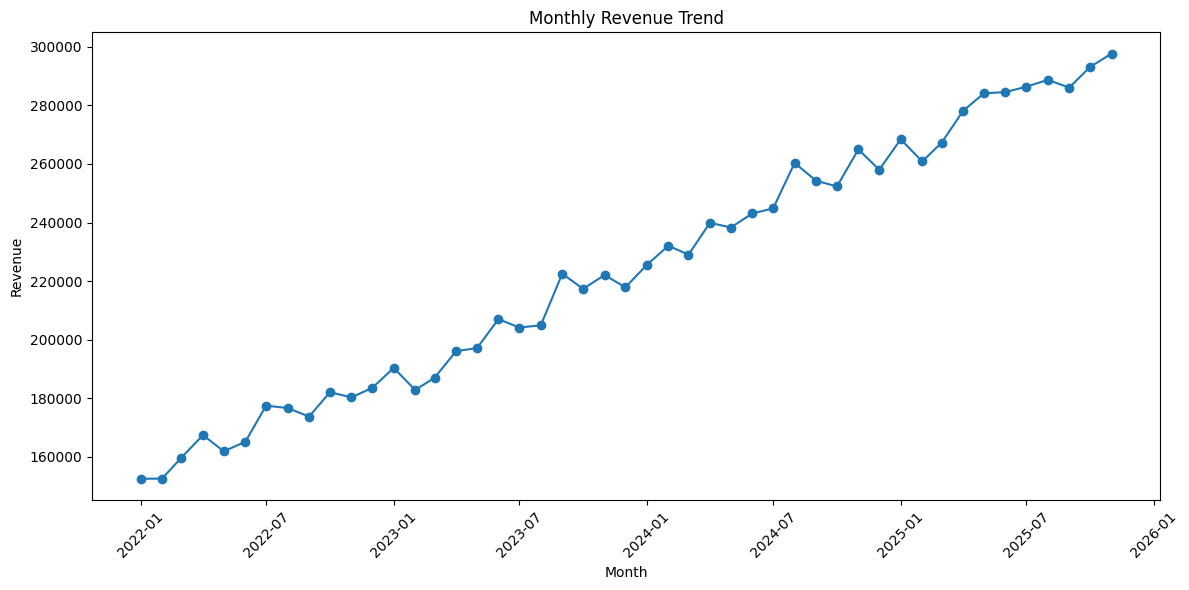

In [10]:
if date_col:
    trend = df.copy()
    trend[date_col] = pd.to_datetime(trend[date_col], errors='coerce')
    trend = trend.dropna(subset=[date_col]).sort_values(date_col)

    if revenue_col:
        monthly = trend.set_index(date_col)[revenue_col].resample('MS').sum()
        plt.figure(figsize=(12, 6))
        plt.plot(monthly.index, monthly.values, marker='o')
        plt.title('Monthly Revenue Trend')
        plt.xlabel('Month')
        plt.ylabel('Revenue')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('No Revenue/Sales column detected.')
else:
    print('No date/month/period column detected.')


## 9. Correlation analysis for numeric drivers

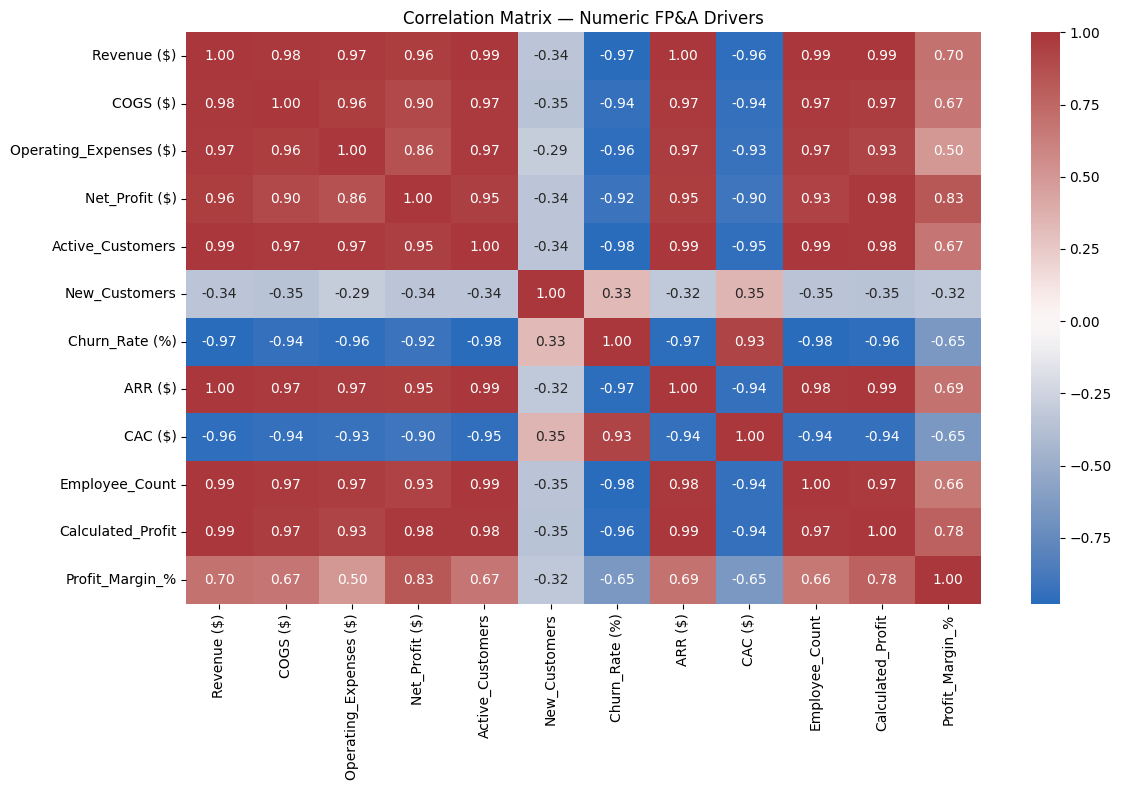

In [11]:
numeric_df = df.select_dtypes(include='number')

if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr(numeric_only=True)
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
    plt.title('Correlation Matrix — Numeric FP&A Drivers')
    plt.tight_layout()
    plt.show()
else:
    print('At least two numeric columns are needed.')


## 10. Export the cleaned and analysed data

In [15]:
output_file = 'FP&A_Analysis_Output.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Analysed_Data', index=False)
    kpi_df.to_excel(writer, sheet_name='KPI_Summary', index=False)
    if department_col and 'Variance' in df.columns:
        variance_summary.to_excel(writer, sheet_name='Variance_by_BU', index=False)

files.download(output_file)
print(f'Created: {output_file}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created: FP&A_Analysis_Output.xlsx


# 1. Fetching & Normalizing Stock Market Data

/tmp/ipykernel_1543/46638411.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  2 of 2 completed


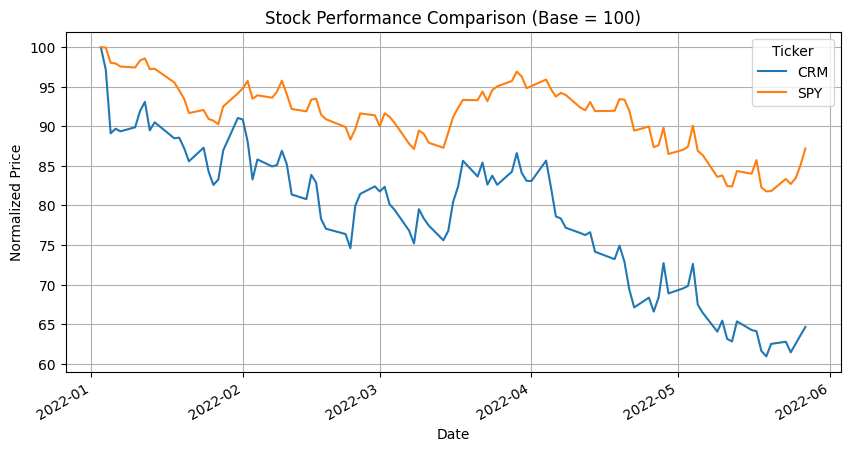

In [23]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download stock data (S&P 500 ETF and Salesforce)
tickers = ['SPY', 'CRM']
data = yf.download(tickers, start="2022-01-01", end="2022-05-30")['Close']

# Normalize data to start at 100
normalized_data = (data / data.iloc[0]) * 100

# Plot performance chart
normalized_data.plot(figsize=(10, 5), title="Stock Performance Comparison (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

#2. Machine Learning Revenue Forecasting

Predicted Revenue for Month 7: $172.00


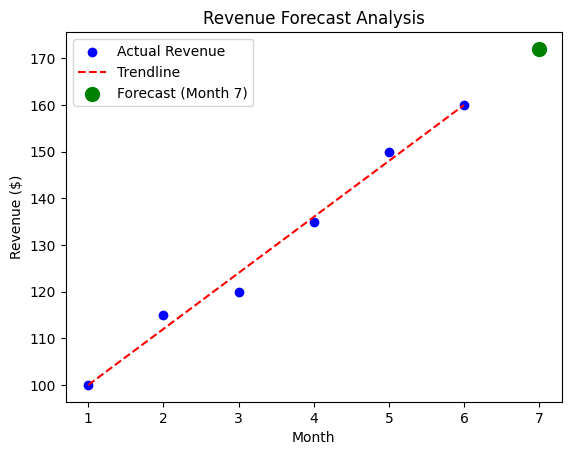

In [24]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Historical Months (1 to 6) and Revenue Data
months = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
revenue = np.array([100, 115, 120, 135, 150, 160])

# Train Machine Learning Model
model = LinearRegression()
model.fit(months, revenue)

# Predict revenue for month 7
next_month = np.array([[7]])
predicted_revenue = model.predict(next_month)
print(f"Predicted Revenue for Month 7: ${predicted_revenue[0]:.2f}")

# Plot Actuals vs Forecast Line
plt.scatter(months, revenue, color='blue', label='Actual Revenue')
plt.plot(months, model.predict(months), color='red', linestyle='--', label='Trendline')
plt.scatter(next_month, predicted_revenue, color='green', marker='o', s=100, label='Forecast (Month 7)')
plt.title("Revenue Forecast Analysis")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.show()

#3. Interactive Financial Visualizations

In [25]:
import plotly.graph_objects as go

# Interactive Line Chart
fig = go.Figure()

fig.add_trace(go.Scatter(x=['Jan', 'Feb', 'Mar', 'Apr'], y=[50, 55, 53, 60], name='COGS', mode='lines+markers'))
fig.add_trace(go.Scatter(x=['Jan', 'Feb', 'Mar', 'Apr'], y=[30, 32, 31, 35], name='OPEX', mode='lines+markers'))
fig.add_trace(go.Scatter(x=['Jan', 'Feb', 'Mar', 'Apr'], y=[20, 23, 26, 25], name='Net Profit', mode='lines+markers'))

fig.update_layout(title="Interactive Financial Metrics Over Time", xaxis_title="Month", yaxis_title="USD ($)")
fig.show()

# Interactive Waterfall Chart
fig_waterfall = go.Figure(go.Waterfall(
    name="P&L",
    orientation="v",
    measure=["relative", "relative", "total", "relative", "total"],
    x=["Revenue", "COGS", "Gross Profit", "OPEX", "Net Income"],
    y=[1000, -400, None, -300, None],
    connector={"line": {"color": "rgb(63, 63, 63)"}},
))

fig_waterfall.update_layout(title="P&L Waterfall Chart", showlegend=False)
fig_waterfall.show()